In [1]:
import os
import numpy as np
import pandas as pd
import cv2
import shutil
import matplotlib.pyplot as plt
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Conv2D, UpSampling2D, Concatenate, BatchNormalization, Activation, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
import csv
import zipfile

tf.get_logger().setLevel('ERROR')

ModuleNotFoundError: No module named 'tqdm'

In [ ]:
DATA_ROOT = "/kaggle/input/tusimple/TUSimple"
CLIPS_PATH = f"/kaggle/input/tusimple/TUSimple/train_set/clips"
PROCESSED_IMGS = "/kaggle/working/processed_images"
MASK_STORAGE = "/kaggle/working/mask_images"
TEST_INPUT = f"/kaggle/input/tusimple/TUSimple/test_set/clips/0530/1492626047222176976_0"
VIDEO_SAVE = "/kaggle/working/output_video/lane_output.mp4"

os.makedirs(PROCESSED_IMGS, exist_ok=True)
os.makedirs(MASK_STORAGE, exist_ok=True)
os.makedirs(os.path.dirname(VIDEO_SAVE), exist_ok=True)

In [ ]:
json_files = [
    f"/kaggle/input/tusimple/TUSimple/train_set/label_data_0313.json",
    f"/kaggle/input/tusimple/TUSimple/train_set/label_data_0531.json",
    f"/kaggle/input/tusimple/TUSimple/train_set/label_data_0601.json"
]
data_frame = pd.concat([pd.read_json(f, lines=True) for f in json_files], ignore_index=True)

In [ ]:
def gather_images():
    if os.listdir(PROCESSED_IMGS):  # Skip if already processed
        return
    for raw_path in tqdm(data_frame['raw_file'], desc="Copying images"):
        clean_path = raw_path.replace('\\', '/')
        src = os.path.join(DATA_ROOT, "train_set", clean_path)  # <- this is the real path

        if os.path.isfile(src):
            clip, frame = clean_path.split('/')[-2:]
            new_name = f"{clip}_{frame}"
            dst = os.path.join(PROCESSED_IMGS, new_name)
            shutil.copy(src, dst)

gather_images()

Copying images: 100%|██████████| 3626/3626 [00:39<00:00, 92.65it/s] 


In [ ]:

def build_masks(dataset):
    if os.listdir(MASK_STORAGE):
        return
    for _, row in tqdm(dataset.iterrows(), total=len(dataset), desc="Building masks"):
        mask = np.zeros((720, 1280), dtype=np.uint8)
        lanes = row['lanes']
        ys = row['h_samples']
        raw_path = row['raw_file'].replace('\\', '/')
        for lane in lanes:
            pts = [(x, y) for x, y in zip(lane, ys) if x >= 0]
            if pts:
                pts = np.array(pts, dtype=np.int32)
                cv2.polylines(mask, [pts], False, 255, thickness=8)
        clip, frame = raw_path.split('/')[-2:]
        name = f"{clip}_{frame}"
        cv2.imwrite(os.path.join(MASK_STORAGE, name), mask)

build_masks(data_frame)

Building masks: 100%|██████████| 3626/3626 [00:06<00:00, 526.30it/s]


In [ ]:
print("Images:", sorted(os.listdir(PROCESSED_IMGS))[:5])
print("Masks:", sorted(os.listdir(MASK_STORAGE))[:5])

image_filenames = sorted(os.listdir(PROCESSED_IMGS))
mask_filenames = sorted(os.listdir(MASK_STORAGE))

common = set(image_filenames) & set(mask_filenames)
print("Common filenames:", list(common)[:5])  # ✅ should not be empty now

img_paths = [os.path.join(PROCESSED_IMGS, f) for f in common]
mask_paths = [os.path.join(MASK_STORAGE, f) for f in common]


Images: ['10000_20.jpg', '1000_20.jpg', '10020_20.jpg', '10040_20.jpg', '1005_20.jpg']
Masks: ['10000_20.jpg', '1000_20.jpg', '10020_20.jpg', '10040_20.jpg', '1005_20.jpg']
Common filenames: ['11420_20.jpg', '1494452675464849156_20.jpg', '41080_20.jpg', '1492637042327291983_20.jpg', '1492635944922779912_20.jpg']


In [ ]:
print("Images:", sorted(os.listdir(PROCESSED_IMGS))[:5])
print("Masks:", sorted(os.listdir(MASK_STORAGE))[:5])


Images: ['10000_20.jpg', '1000_20.jpg', '10020_20.jpg', '10040_20.jpg', '1005_20.jpg']
Masks: ['10000_20.jpg', '1000_20.jpg', '10020_20.jpg', '10040_20.jpg', '1005_20.jpg']


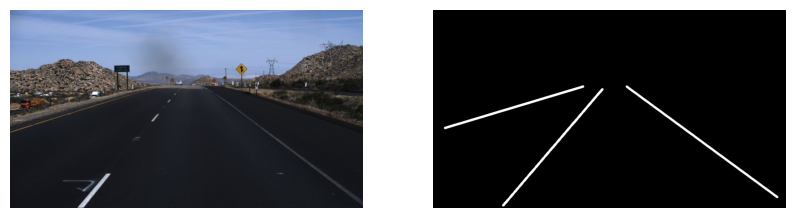

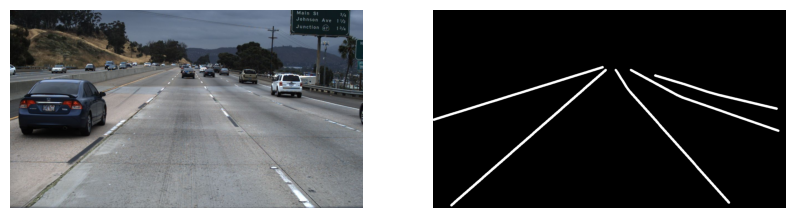

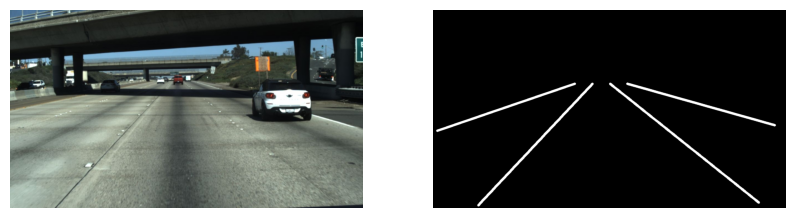

In [ ]:
def display_samples(count=3):
    names = os.listdir(PROCESSED_IMGS)
    if not names:
        return
    selected = np.random.choice(names, min(count, len(names)), replace=False)
    for name in selected:
        img = cv2.cvtColor(cv2.imread(os.path.join(PROCESSED_IMGS, name)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(os.path.join(MASK_STORAGE, name), cv2.IMREAD_GRAYSCALE)
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.axis('off')
        plt.subplot(1, 2, 2)
        plt.imshow(mask, cmap='gray')
        plt.axis('off')
        plt.show()

display_samples()


In [ ]:
image_filenames = sorted(os.listdir(PROCESSED_IMGS))
mask_filenames = sorted(os.listdir(MASK_STORAGE))

# Keep only files that exist in both
common = set(image_filenames) & set(mask_filenames)
common = sorted(common)

img_paths = [os.path.join(PROCESSED_IMGS, f) for f in common]
mask_paths = [os.path.join(MASK_STORAGE, f) for f in common]

print("Total paired samples:", len(img_paths))


Total paired samples: 2910


In [ ]:
def construct_network(input_size=(224, 224, 3)):
    def block(filters, x):
        x = Conv2D(filters, 3, padding='same', kernel_initializer='he_normal')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Dropout(0.3)(x)
        return x

    base = ResNet50(weights='imagenet', include_top=False, input_shape=input_size)
    for layer in base.layers:
        layer.trainable = True

    i = base.input
    f1 = base.get_layer('conv1_relu').output
    f2 = base.get_layer('conv2_block3_out').output
    f3 = base.get_layer('conv3_block4_out').output
    f4 = base.get_layer('conv4_block6_out').output
    f5 = base.get_layer('conv5_block3_out').output

    u1 = UpSampling2D(2)(f5)
    m1 = Concatenate()([u1, f4])
    c1 = block(512, m1)

    u2 = UpSampling2D(2)(c1)
    m2 = Concatenate()([u2, f3])
    c2 = block(256, m2)

    u3 = UpSampling2D(2)(c2)
    m3 = Concatenate()([u3, f2])
    c3 = block(128, m3)

    u4 = UpSampling2D(2)(c3)
    m4 = Concatenate()([u4, f1])
    c4 = block(64, m4)

    out = UpSampling2D(2)(c4)
    out = Conv2D(1, 1, activation='sigmoid')(out)
    return Model(i, out)

network = construct_network()

I0000 00:00:1754560833.733176      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def dice(y_true, y_pred):
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred[..., 0])
    i = tf.reduce_sum(y_true * y_pred)
    return (2. * i + 1.) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1.)

def loss(y_true, y_pred):
    return 1. - dice(y_true, y_pred)

def precision(y_true, y_pred):
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred[..., 0])
    tp = tf.reduce_sum(y_true * y_pred)
    return tp / (tf.reduce_sum(y_pred) + tf.keras.backend.epsilon())

def recall(y_true, y_pred):
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred[..., 0])
    tp = tf.reduce_sum(y_true * y_pred)
    return tp / (tf.reduce_sum(y_true) + tf.keras.backend.epsilon())

network.compile(optimizer='adam', loss=loss, metrics=[dice, precision, recall, 'accuracy'])

In [ ]:
def prepare_data(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_jpeg(mask, channels=1)
    mask = tf.image.resize(mask, [224, 224], method='nearest')
    mask = tf.cast(mask, tf.float32) / 255.0

    return img, mask


img_paths = [os.path.join(PROCESSED_IMGS, f) for f in os.listdir(PROCESSED_IMGS)]
mask_paths = [os.path.join(MASK_STORAGE, f) for f in os.listdir(MASK_STORAGE)]

train_imgs, val_imgs, train_masks, val_masks = train_test_split(img_paths, mask_paths, test_size=0.2, random_state=42)

train_set = tf.data.Dataset.from_tensor_slices((train_imgs, train_masks))
train_set = train_set.map(prepare_data, num_parallel_calls=tf.data.AUTOTUNE).batch(8).prefetch(tf.data.AUTOTUNE)

val_set = tf.data.Dataset.from_tensor_slices((val_imgs, val_masks))
val_set = val_set.map(prepare_data, num_parallel_calls=tf.data.AUTOTUNE).batch(8).prefetch(tf.data.AUTOTUNE)

In [ ]:
print("Images:", len(img_paths))
print("Masks:", len(mask_paths))


Images: 2910
Masks: 2910


In [ ]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint


ModuleNotFoundError: No module named 'distutils'